# ChurnLens AI
### Explainable Customer Churn Prediction

This project aims to predict which customers are likely to leave a telecommunications company and understand the reasons behind those predictions.

**Dataset:** IBM Telco Customer Churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.__version__

'2.0.3'

In [3]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("dataset shape: ", df.shape)
print("\nColumn names: ")
print(df.columns.tolist())

dataset shape:  (7043, 21)

Column names: 
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [7]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Data type:", df["TotalCharges"].dtype)
print("Missing values:", df["TotalCharges"].isna().sum())

Data type: float64
Missing values: 0


In [8]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
print("Duplicate rows: ", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows:  0
Duplicate customer IDs: 0


In [10]:
df["Churn"].value_counts()

print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [11]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


In [12]:
print("Contract types:")
print(df["Contract"].value_counts())

print("\nContract percentages:")
print((df["Contract"].value_counts(normalize=True) * 100).round(2))

Contract types:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Contract percentages:
Contract
Month-to-month    55.02
Two year          24.07
One year          20.91
Name: proportion, dtype: float64


In [13]:
pd.crosstab(
    df["Contract"],
    df["Churn"]
)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [14]:
#What percentage of customers churned within each contract type?
pd.crosstab(df["Contract"],df["Churn"],normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [15]:
#Check how many customers use each type of internet service
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [16]:
#Check churn percentage for each internet service type
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [17]:
#Check how many customers use each payment method
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [18]:
#Check churn percentage for each payment method
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [19]:
#Compare average customer tenure between churned and non-churned customers
df.groupby("Churn")["tenure"].mean().round(2)

Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64

In [20]:
#Compare average monthly charges between churned and non-churned customers
df.groupby("Churn")["MonthlyCharges"].mean().round(2)

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

In [21]:
#Compare average total charges between churned and non-churned customers
df.groupby("Churn")["TotalCharges"].mean().round(2)

Churn
No     2549.91
Yes    1531.80
Name: TotalCharges, dtype: float64

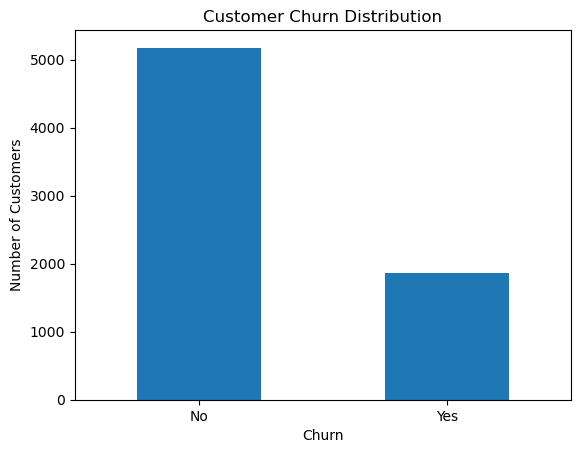

In [22]:
#Visualize the number of customers who stayed and churned
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

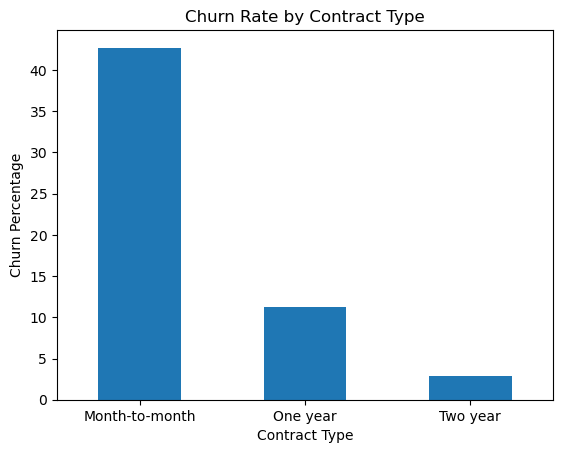

In [23]:
#Visualize churn percentage for each contract type
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

contract_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)

plt.show()

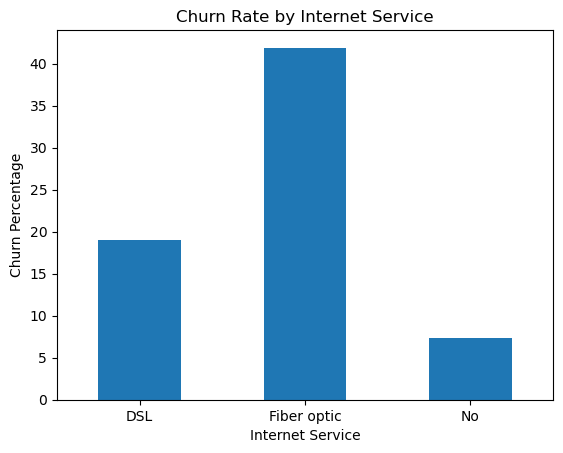

In [24]:
#Visualize churn percentage for each internet service type
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

internet_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)

plt.show()

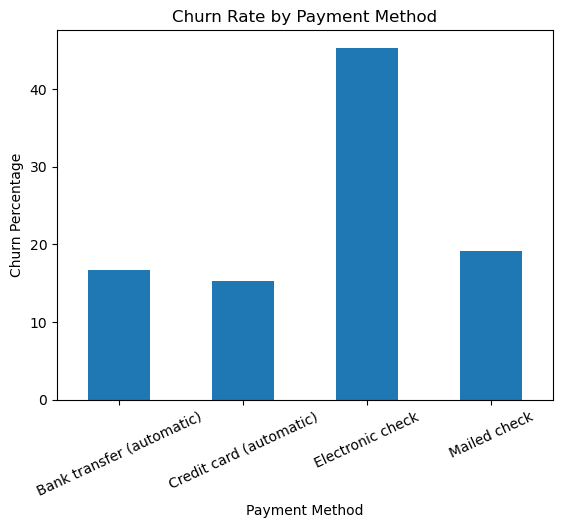

In [25]:
#Visualize churn percentage for each payment method
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

payment_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=25)

plt.show()

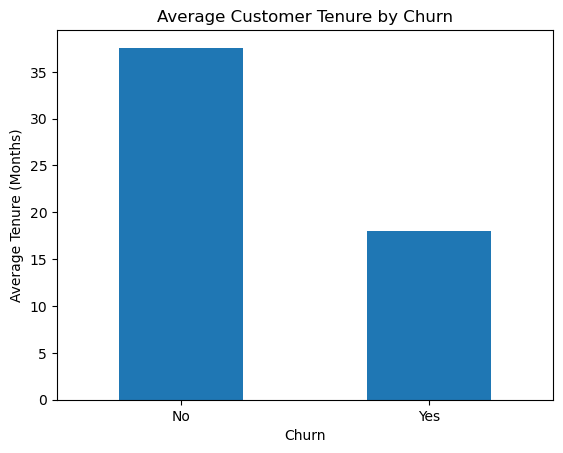

In [26]:
#Visualize average tenure for churned and non-churned customers
df.groupby("Churn")["tenure"].mean().plot(kind="bar")

plt.title("Average Customer Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)

plt.show()

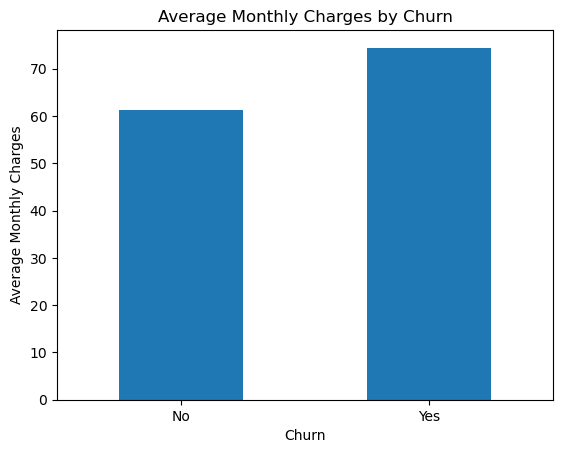

In [27]:
#Visualize average monthly charges for churned and non-churned customers
df.groupby("Churn")["MonthlyCharges"].mean().plot(kind="bar")

plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)

plt.show()

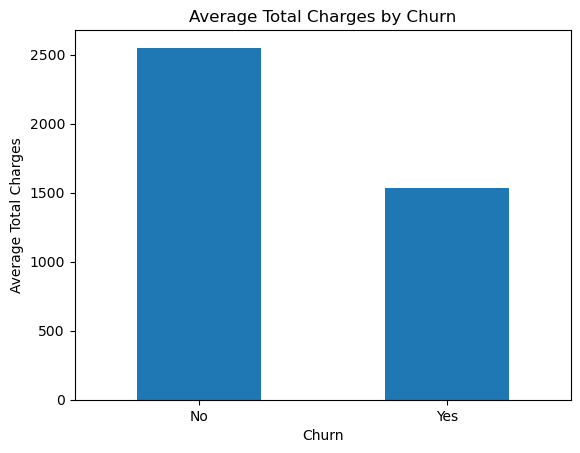

In [28]:
#Visualize average total charges for churned and non-churned customers
df.groupby("Churn")["TotalCharges"].mean().plot(kind="bar")

plt.title("Average Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Total Charges")
plt.xticks(rotation=0)

plt.show()

In [29]:
#Check churn percentage based on whether customers use paperless billing
pd.crosstab(df["PaperlessBilling"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


In [30]:
#Check churn percentage for senior and non-senior customers
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [31]:
#Check churn percentage based on whether customers have a partner
pd.crosstab(df["Partner"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [32]:
#Check churn percentage based on whether customers have dependents
pd.crosstab(df["Dependents"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


In [33]:
#Check churn percentage based on whether customers have tech support
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [34]:
#Check churn percentage based on online security service
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index") * 100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [35]:
#Check churn percentage based on online backup service
pd.crosstab(df["OnlineBackup"], df["Churn"], normalize="index") * 100

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


In [36]:
#Check churn percentage based on device protection service
pd.crosstab(df["DeviceProtection"], df["Churn"], normalize="index") * 100

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


In [37]:
#Check churn percentage based on streaming TV service
pd.crosstab(df["StreamingTV"], df["Churn"], normalize="index") * 100

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


In [38]:
#Check churn percentage based on streaming movies service
pd.crosstab(df["StreamingMovies"], df["Churn"], normalize="index") * 100

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


In [39]:
#Check churn percentage based on phone service
pd.crosstab(df["PhoneService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


In [40]:
#Check churn percentage based on multiple phone lines
pd.crosstab(df["MultipleLines"], df["Churn"], normalize="index") * 100

Churn,No,Yes
MultipleLines,,
No,74.955752,25.044248
No phone service,75.073314,24.926686
Yes,71.390104,28.609896


In [41]:
#Check churn percentage based on customer gender
pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [42]:
#Compare average numerical features between churned and non-churned customers
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80


In [43]:
#Final check of dataset structure after cleaning and exploration
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [44]:
#Separate the input features and the churn target
X = df.drop(["customerID", "Churn"], axis=1)

y = df["Churn"].map({"No": 0, "Yes": 1})

#Check the prepared input and target sizes
print("X shape:", X.shape)
print("y shape:", y.shape)

y.value_counts()

X shape: (7043, 19)
y shape: (7043,)


Churn
0    5174
1    1869
Name: count, dtype: int64

In [45]:
#Check which input features are numerical and categorical
print("Numerical columns:")
print(X.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [46]:
#Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [47]:
#Check the sizes of the training and testing sets
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [48]:
#Separate the numerical and categorical feature names
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numerical_cols)
print("\nCategorical features:", categorical_cols)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [49]:
#Create preprocessing steps for numerical and categorical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [50]:
#Create the first machine learning pipeline using Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [51]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                               

In [52]:
#Make churn predictions on the test data
y_pred = logistic_model.predict(X_test)

print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [53]:
#Compare the first 20 predicted churn results with the actual results
comparison = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

comparison

,Actual,Predicted
0,0,0
1,0,1
2,0,0
3,0,0
4,0,0
5,0,1
6,0,0
7,0,0
8,0,0
9,1,0


In [54]:
#Check the overall accuracy of the Logistic Regression model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 80.55 %


In [55]:
#Check how many churn and non-churn predictions were correct or incorrect
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [165 209]]


In [56]:
#Evaluate the Logistic Regression model using key performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

Accuracy: 80.55 %
Precision: 65.72 %
Recall: 55.88 %
F1 Score: 60.4 %


In [57]:
#Create a Random Forest machine learning pipeline
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [58]:
#Train the Random Forest model
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                               

In [59]:
#Make churn predictions using the Random Forest model
rf_pred = random_forest_model.predict(X_test)

print(rf_pred[:20])

[0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [60]:
#Evaluate the Random Forest model using the same performance metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy:", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall:", round(rf_recall * 100, 2), "%")
print("F1 Score:", round(rf_f1 * 100, 2), "%")

Accuracy: 78.35 %
Precision: 61.86 %
Recall: 48.13 %
F1 Score: 54.14 %


In [61]:
#Compare Logistic Regression and Random Forest performance
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall],
    "F1 Score": [f1, rf_f1]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806,0.657,0.559,0.604
1,Random Forest,0.784,0.619,0.481,0.541


In [62]:
#Create a balanced Logistic Regression model to give more importance to churned customers
balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

In [63]:
#Train the balanced Logistic Regression model
balanced_logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                               

In [64]:
#Make churn predictions using the balanced Logistic Regression model
balanced_pred = balanced_logistic_model.predict(X_test)

print(balanced_pred[:20])

[0 1 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0]


In [65]:
#Evaluate the balanced Logistic Regression model
balanced_accuracy = accuracy_score(y_test, balanced_pred)
balanced_precision = precision_score(y_test, balanced_pred)
balanced_recall = recall_score(y_test, balanced_pred)
balanced_f1 = f1_score(y_test, balanced_pred)

print("Accuracy:", round(balanced_accuracy * 100, 2), "%")
print("Precision:", round(balanced_precision * 100, 2), "%")
print("Recall:", round(balanced_recall * 100, 2), "%")
print("F1 Score:", round(balanced_f1 * 100, 2), "%")

Accuracy: 73.81 %
Precision: 50.43 %
Recall: 78.34 %
F1 Score: 61.36 %


In [66]:
#Compare all models tested so far
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        balanced_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        balanced_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        balanced_recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        balanced_f1,
        rf_f1
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806,0.657,0.559,0.604
1,Balanced Logistic Regression,0.738,0.504,0.783,0.614
2,Random Forest,0.784,0.619,0.481,0.541


In [67]:
#Install XGBoost in the current Jupyter environment
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [68]:
#Create an XGBoost machine learning pipeline
from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

In [69]:
#Train the XGBoost model
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                               

In [70]:
#Make churn predictions using the XGBoost model
xgb_pred = xgb_model.predict(X_test)

print(xgb_pred[:20])

[0 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [71]:
#Evaluate the XGBoost model
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("Accuracy:", round(xgb_accuracy * 100, 2), "%")
print("Precision:", round(xgb_precision * 100, 2), "%")
print("Recall:", round(xgb_recall * 100, 2), "%")
print("F1 Score:", round(xgb_f1 * 100, 2), "%")

Accuracy: 80.27 %
Precision: 66.22 %
Recall: 52.41 %
F1 Score: 58.51 %


In [72]:
#Compare all machine learning models tested so far
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        balanced_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        balanced_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        balanced_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        balanced_f1,
        rf_f1,
        xgb_f1
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806,0.657,0.559,0.604
1,Balanced Logistic Regression,0.738,0.504,0.783,0.614
2,Random Forest,0.784,0.619,0.481,0.541
3,XGBoost,0.803,0.662,0.524,0.585


In [73]:
#Find which features have the strongest influence on churn predictions
feature_names = balanced_logistic_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = balanced_logistic_model.named_steps["model"].coef_[0]

feature_effects = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_effects["Importance"] = feature_effects["Coefficient"].abs()

feature_effects.sort_values("Importance", ascending=False).head(15)

,Feature,Coefficient,Importance
1,num__tenure,-1.154360,1.154360
16,cat__InternetService_Fiber optic,0.787288,0.787288
36,cat__Contract_Month-to-month,0.720661,0.720661
38,cat__Contract_Two year,-0.712204,0.712204
2,num__MonthlyCharges,-0.709822,0.709822
15,cat__InternetService_DSL,-0.569594,0.569594
3,num__TotalCharges,0.488833,0.488833
35,cat__StreamingMovies_Yes,0.347102,0.347102
32,cat__StreamingTV_Yes,0.334295,0.334295
43,cat__PaymentMethod_Electronic check,0.287549,0.287549


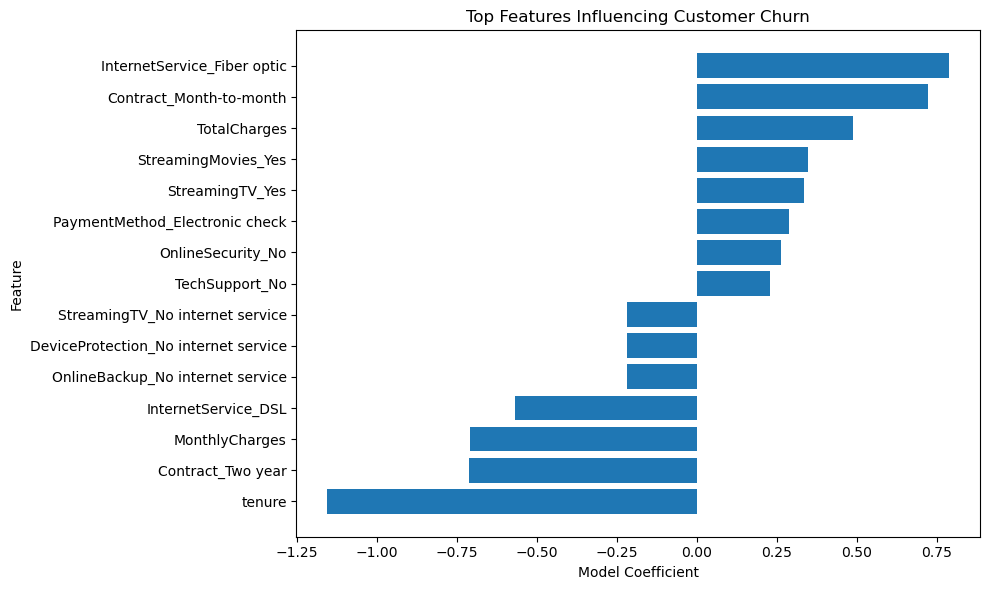

In [74]:
#Visualize the most influential features in the Balanced Logistic Regression model
top_features = feature_effects.sort_values("Importance", ascending=False).head(15).copy()

top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_features = top_features.sort_values("Coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Coefficient"])

plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Model Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [75]:
#Prepare the processed training and test data for SHAP explanations
feature_names = balanced_logistic_model.named_steps["preprocessor"].get_feature_names_out()

X_train_processed = balanced_logistic_model.named_steps["preprocessor"].transform(X_train)
X_test_processed = balanced_logistic_model.named_steps["preprocessor"].transform(X_test)

X_train_shap = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_shap = pd.DataFrame(X_test_processed, columns=feature_names)

print("Training data:", X_train_shap.shape)
print("Test data:", X_test_shap.shape)

Training data: (5634, 45)
Test data: (1409, 45)


In [77]:
#Import SHAP for explainable AI
import shap

In [78]:
#Import SHAP and create an explainer for the Balanced Logistic Regression model
import shap

model = balanced_logistic_model.named_steps["model"]

explainer = shap.LinearExplainer(model, X_train_shap)
shap_values = explainer(X_test_shap)

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (1409, 45)


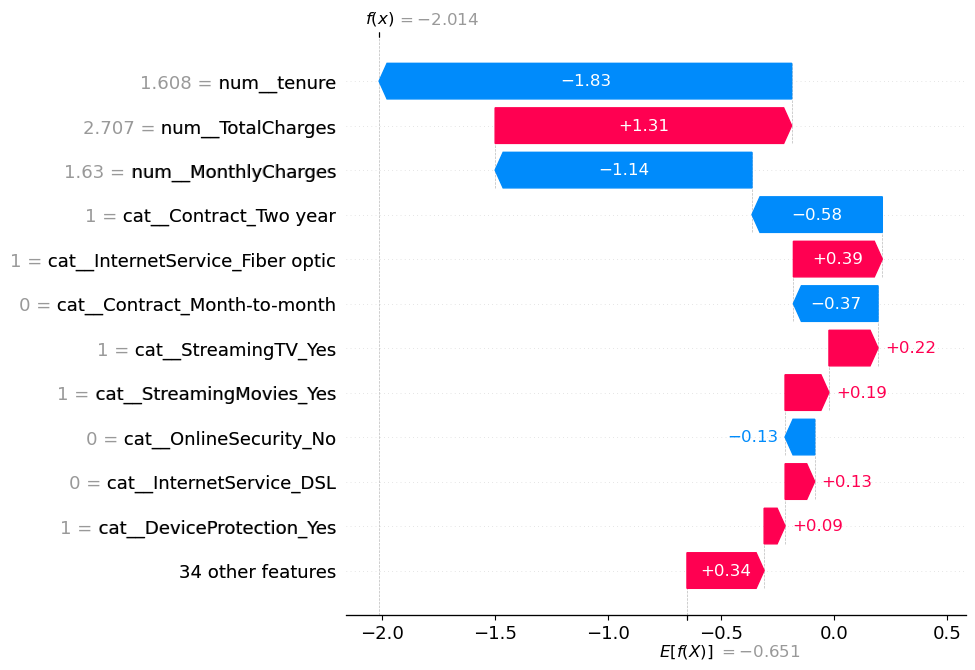

In [79]:
#Explain the first customer's churn prediction using SHAP
shap.plots.waterfall(shap_values[0], max_display=12)

In [80]:
#Find the test customer with the highest predicted churn risk
churn_probabilities = balanced_logistic_model.predict_proba(X_test)[:, 1]

high_risk_position = churn_probabilities.argmax()

print("Test set position:", high_risk_position)
print("Churn probability:", round(churn_probabilities[high_risk_position] * 100, 2), "%")
print("Actual result:", y_test.iloc[high_risk_position])

Test set position: 1090
Churn probability: 93.78 %
Actual result: 1


In [81]:
#View the highest-risk customer's original details
high_risk_customer = X_test.iloc[high_risk_position]

high_risk_customer

gender                          Male
SeniorCitizen                      1
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                  95.1
TotalCharges                    95.1
Name: 3380, dtype: object

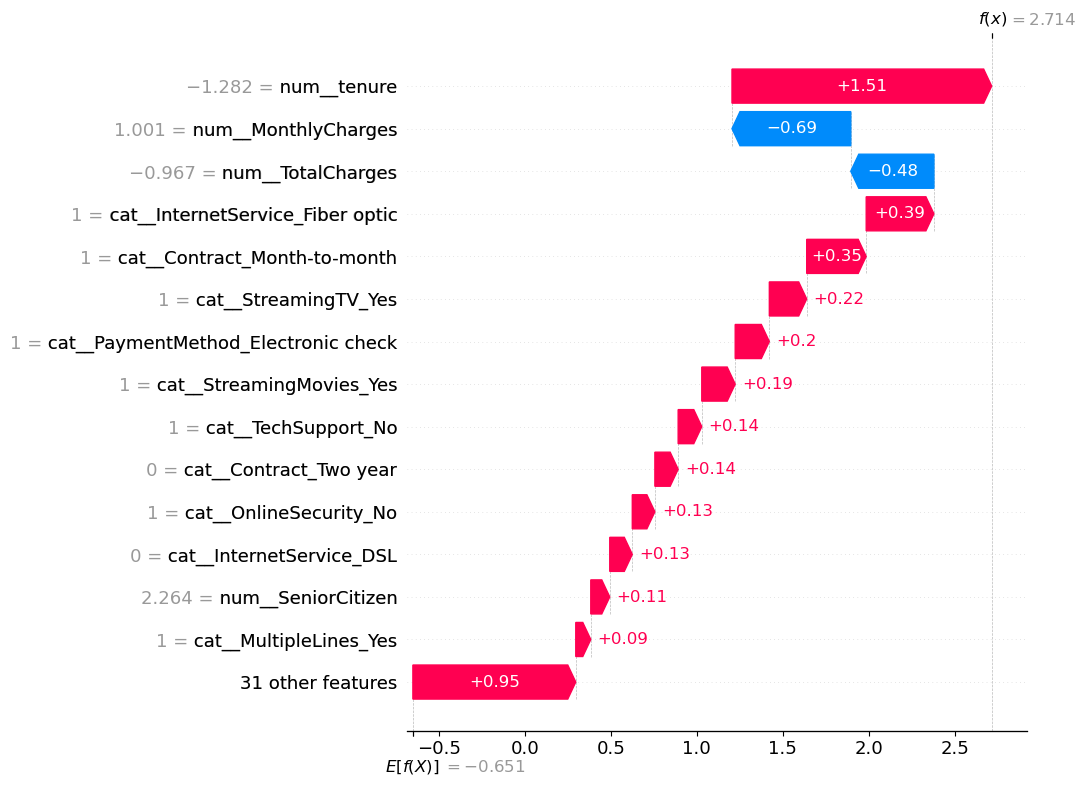

In [82]:
#Explain why the highest-risk customer was predicted to churn
shap.plots.waterfall(
    shap_values[high_risk_position],
    max_display=15
)

In [83]:
#Create a readable summary of the highest-risk customer
customer_summary = pd.DataFrame({
    "Feature": [
        "Tenure",
        "Contract",
        "Internet Service",
        "Monthly Charges",
        "Payment Method",
        "Tech Support",
        "Online Security",
        "Online Backup",
        "Device Protection"
    ],
    "Value": [
        f"{high_risk_customer['tenure']} month(s)",
        high_risk_customer["Contract"],
        high_risk_customer["InternetService"],
        f"${high_risk_customer['MonthlyCharges']:.2f}",
        high_risk_customer["PaymentMethod"],
        high_risk_customer["TechSupport"],
        high_risk_customer["OnlineSecurity"],
        high_risk_customer["OnlineBackup"],
        high_risk_customer["DeviceProtection"]
    ]
})

customer_summary

,Feature,Value
0,Tenure,1 month(s)
1,Contract,Month-to-month
2,Internet Service,Fiber optic
3,Monthly Charges,$95.10
4,Payment Method,Electronic check
5,Tech Support,No
6,Online Security,No
7,Online Backup,No
8,Device Protection,No


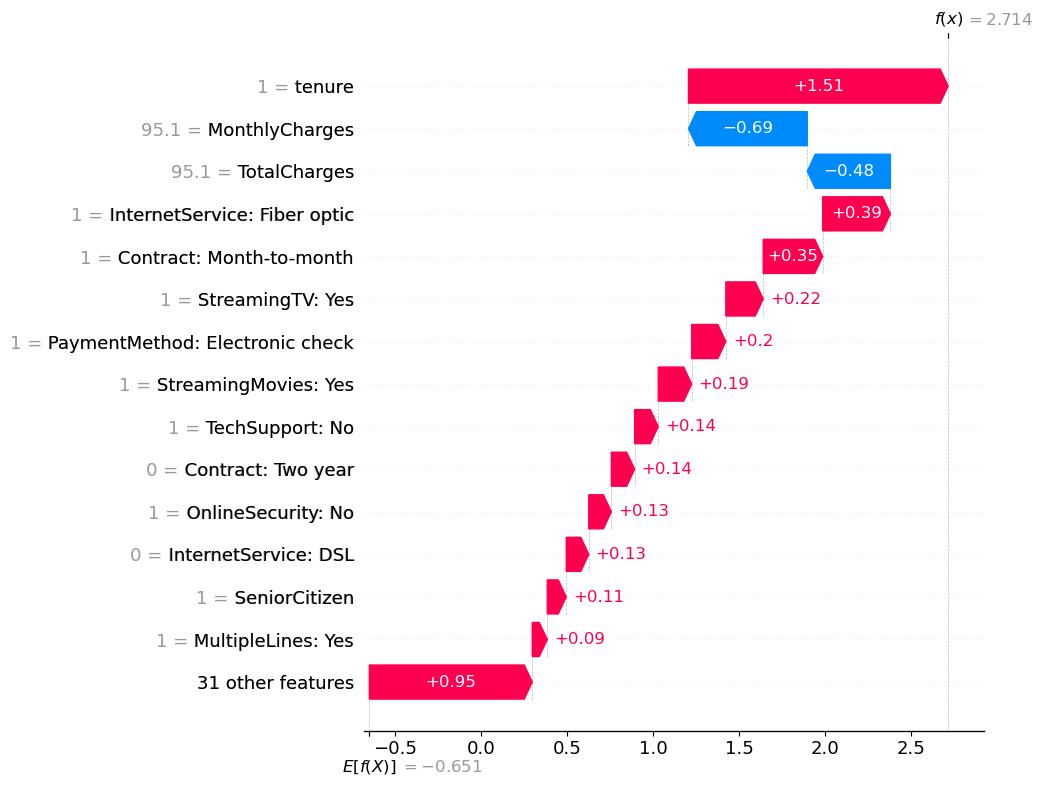

In [84]:
#Create a more readable SHAP explanation for the highest-risk customer
readable_names = []

for name in feature_names:
    name = name.replace("num__", "").replace("cat__", "")
    name = name.replace("_", ": ")
    readable_names.append(name)

display_values = shap_values[high_risk_position].data.copy()

for column in numerical_cols:
    position = list(feature_names).index("num__" + column)
    display_values[position] = high_risk_customer[column]

readable_explanation = shap.Explanation(
    values=shap_values[high_risk_position].values,
    base_values=shap_values[high_risk_position].base_values,
    data=display_values,
    feature_names=readable_names
)

shap.plots.waterfall(readable_explanation, max_display=15)

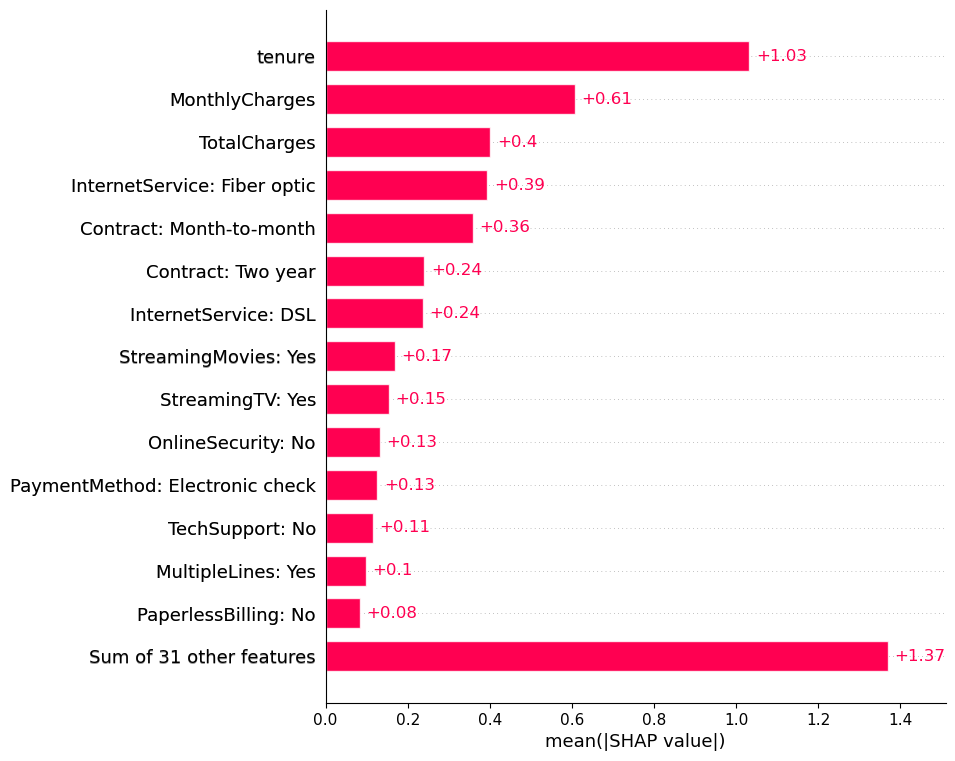

In [85]:
#Create readable SHAP values for all test customers
shap_values_readable = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=shap_values.data,
    feature_names=readable_names
)

#Visualize the most important features across all test customers
shap.plots.bar(shap_values_readable, max_display=15)

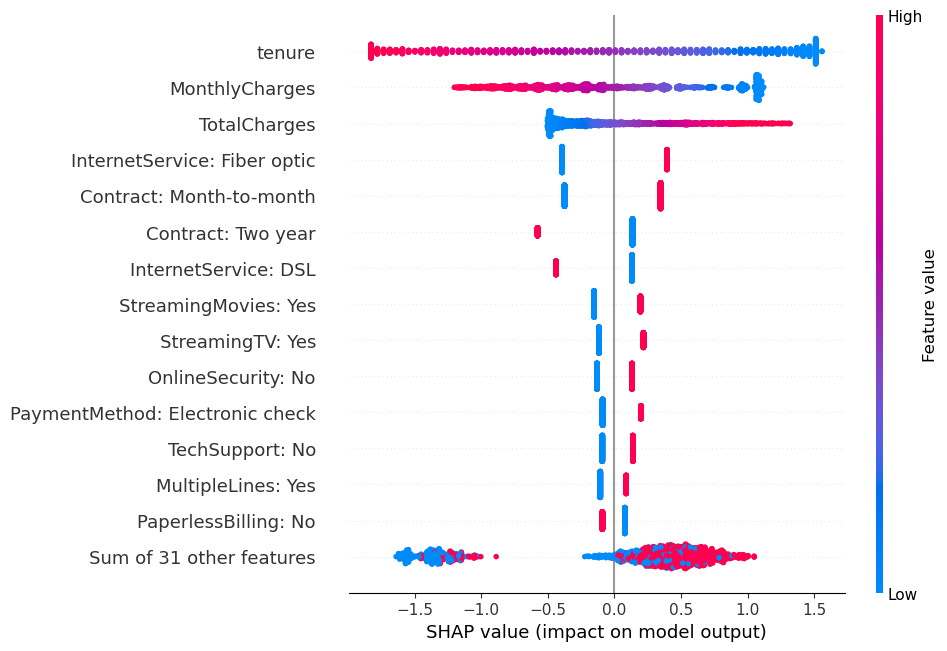

In [86]:
#Show how important features push predictions toward churn or staying
shap.plots.beeswarm(
    shap_values_readable,
    max_display=15
)

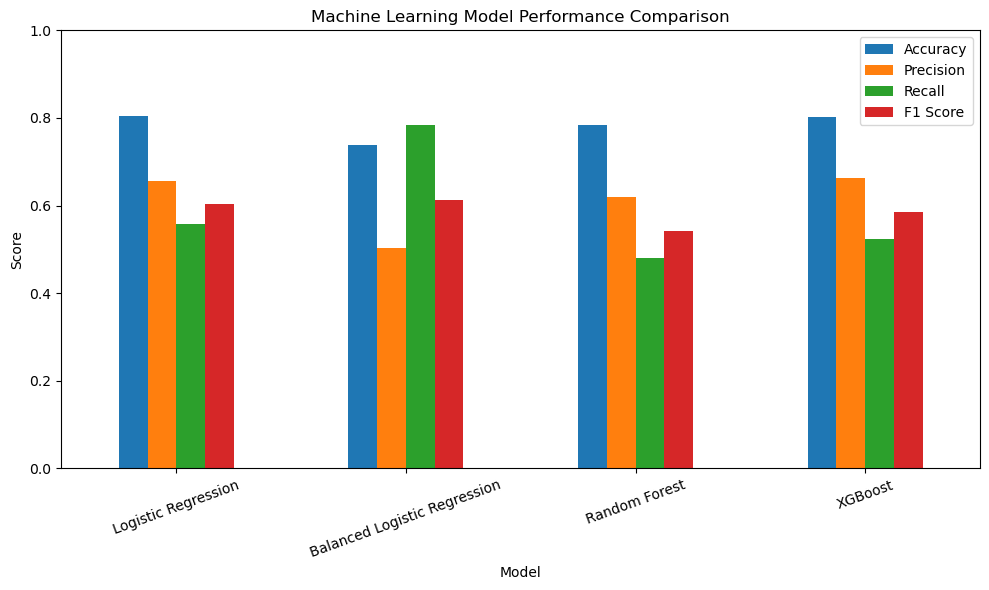

In [87]:
#Visualize the performance of all tested machine learning models
comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

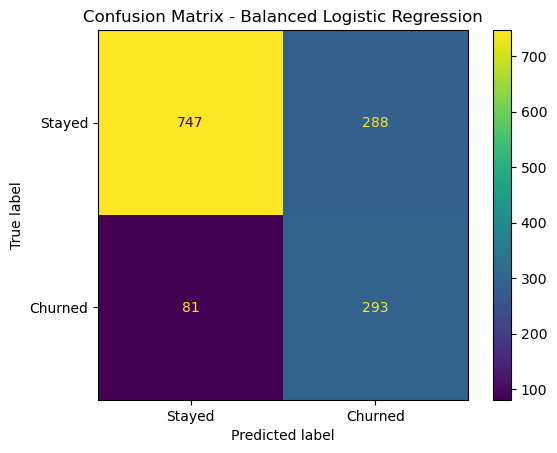

In [88]:
#Visualize the confusion matrix for the Balanced Logistic Regression model
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    balanced_pred,
    display_labels=["Stayed", "Churned"]
)

plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

## Final Project Summary

ChurnLens AI was developed to predict customer churn and explain the factors influencing those predictions.

Several machine learning models were evaluated, including Logistic Regression, Balanced Logistic Regression, Random Forest, and XGBoost.

The standard Logistic Regression model achieved the highest overall accuracy of approximately **80.6%**, while the Balanced Logistic Regression model achieved the highest churn recall of approximately **78.3%** and the best F1 score of approximately **61.4%**.

For a customer retention problem, identifying customers who are genuinely at risk of leaving is particularly important. Therefore, the Balanced Logistic Regression model was selected as the main explainable churn model.

### Key Findings

- Customers with shorter tenure showed a higher risk of churn.
- Month-to-month contracts were strongly associated with higher churn.
- Fiber optic customers showed higher churn rates than DSL customers.
- Electronic check users had a higher churn rate than customers using other payment methods.
- Customers without Tech Support or Online Security were more likely to churn.
- Longer-term contracts were associated with significantly lower churn.

SHAP was used to explain both overall model behaviour and individual customer predictions. This allows ChurnLens AI to provide not only a churn prediction, but also an explanation of the factors contributing to that prediction.

### Business Use

A telecommunications company could use a system like ChurnLens AI to identify high-risk customers before they leave and focus retention efforts on the customers who are most likely to churn.